# Historical VaR & CVaR

This section will calculates 95% Historical Value at Risk (VaR) and Conditional Value at Risk (CVaR).


In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("../data/db/bluestock_mf.db")

In [2]:
nav = pd.read_sql("""
SELECT amfi_code,date,nav
FROM fact_nav
""", conn)

nav["date"] = pd.to_datetime(nav["date"])

results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    returns = grp["nav"].pct_change().dropna()

    if len(returns) < 30:
        continue

    var95 = np.percentile(returns, 5)

    cvar95 = returns[returns <= var95].mean()

    results.append([code, var95, cvar95])

risk_df = pd.DataFrame(
    results,
    columns=["amfi_code","VaR_95","CVaR_95"]
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


# Rolling Sharpe Ratio

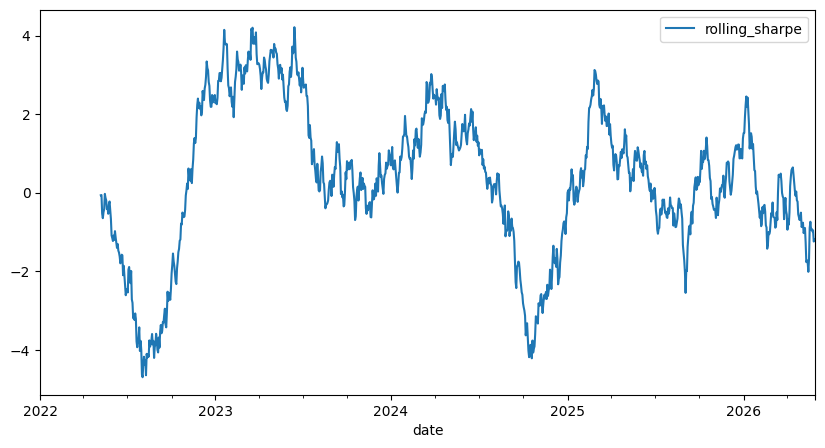

In [3]:
sample_code = nav["amfi_code"].iloc[0]

fund = nav[
    nav["amfi_code"] == sample_code
].copy()

fund = fund.sort_values("date")

fund["returns"] = fund["nav"].pct_change()

fund["rolling_sharpe"] = (
    fund["returns"].rolling(90).mean()
    /
    fund["returns"].rolling(90).std()
) * np.sqrt(252)

fund.plot(
    x="date",
    y="rolling_sharpe",
    figsize=(10,5)
)

plt.show()

Cohort Analysis

transactions = pd.read_sql(
    "SELECT * FROM transactions",
    conn
)

transactions["date"] = pd.to_datetime(
    transactions["date"]
)

first_txn = (
    transactions
    .groupby("investor_id")["date"]
    .min()
)

cohort = first_txn.dt.year

cohort_df = transactions.merge(
    cohort.rename("cohort"),
    on="investor_id"
)

cohort_summary = (
    cohort_df
    .groupby("cohort")
    .agg(
        total_investment=("amount","sum"),
        investors=("investor_id","nunique")
    )
)

cohort_summary

# SIP Continuity Analysis

In [4]:
transactions = pd.read_sql("""
SELECT *
FROM fact_transactions
""", conn)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [5]:
latest_date = transactions["transaction_date"].max()

investor_gap = (
    latest_date -
    transactions.groupby("investor_id")["transaction_date"].max()
)

investor_gap = investor_gap.dt.days

investor_status = pd.DataFrame({
    "gap_days": investor_gap
})

investor_status["status"] = np.where(
    investor_status["gap_days"] > 60,
    "At Risk",
    "Active"
)

investor_status["status"].value_counts()

status
Active     2593
At Risk    2407
Name: count, dtype: int64

# Fund Recommender

recommendations = risk_df.copy()

recommendations["score"] = (
    recommendations["VaR_95"]
    -
    recommendations["CVaR_95"]
)

recommendations = recommendations.sort_values(
    "score",
    ascending=False
)

recommendations.head(10)

# Sector HHI

In [6]:
funds = pd.read_sql("""
SELECT *
FROM dim_fund
""", conn)

category_counts = funds["category"].value_counts()

weights = category_counts / category_counts.sum()

hhi = (weights ** 2).sum()

print("Category HHI =", round(hhi, 4))

Category HHI = 0.745


In [7]:
transactions = pd.read_sql("""
SELECT *
FROM fact_transactions
""", conn)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
)

cohort = first_txn.dt.year

cohort_df = transactions.merge(
    cohort.rename("cohort"),
    on="investor_id"
)

cohort_summary = (
    cohort_df
    .groupby("cohort")
    .agg(
        total_investment=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
)

cohort_summary

,total_investment,investors
cohort,,
2024,3491125187,4803
2025,30455243,197


In [8]:
transactions = pd.read_sql("""
SELECT *
FROM fact_transactions
""", conn)

transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
)

cohort = first_txn.dt.year

cohort_df = transactions.merge(
    cohort.rename("cohort"),
    on="investor_id"
)

cohort_summary = (
    cohort_df
    .groupby("cohort")
    .agg(
        total_investment=("amount_inr", "sum"),
        investors=("investor_id", "nunique")
    )
)

cohort_summary

,total_investment,investors
cohort,,
2024,3491125187,4803
2025,30455243,197


In [9]:
latest_date = transactions["transaction_date"].max()

investor_gap = (
    latest_date -
    transactions.groupby("investor_id")["transaction_date"].max()
)

investor_gap = investor_gap.dt.days

investor_status = pd.DataFrame({
    "gap_days": investor_gap
})

investor_status["status"] = np.where(
    investor_status["gap_days"] > 60,
    "At Risk",
    "Active"
)

investor_status["status"].value_counts()

status
Active     2593
At Risk    2407
Name: count, dtype: int64

In [10]:
performance = pd.read_sql("""
SELECT *
FROM fact_performance
""", conn)

top_funds = performance.sort_values(
    ["sharpe_ratio", "return_3yr_pct"],
    ascending=False
)

top_funds[
    [
        "scheme_name",
        "category",
        "return_3yr_pct",
        "sharpe_ratio",
        "risk_grade"
    ]
].head(10)

,scheme_name,category,return_3yr_pct,sharpe_ratio,risk_grade
14,ICICI Pru Liquid Fund - Regular - Growth,Liquid,7.68,7.68,Low
23,Kotak Liquid Fund - Regular - Growth,Liquid,6.18,6.18,Low
30,ABSL Liquid Fund - Regular - Growth,Liquid,5.14,5.14,Low
9,HDFC Short Term Debt Fund - Regular - Growth,Short Duration,7.37,1.84,Low
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Gilt,6.07,1.52,Low
19,Nippon India Gilt Securities Fund - Regular - ...,Gilt,5.31,1.33,Low
5,HDFC Top 100 Fund - Regular Plan - Growth,Large Cap,14.84,1.06,Moderate
34,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,14.81,1.06,Moderate
11,ICICI Pru Bluechip Fund - Direct - Growth,Large Cap,14.41,1.03,Moderate
15,Nippon India Large Cap Fund - Regular - Growth,Large Cap,14.00,1.00,Moderate


In [11]:
print("VaR Funds:", len(risk_df))
print("Cohorts:", len(cohort_summary))
print("Investors:", len(investor_status))
print("Top Funds:", len(top_funds))

VaR Funds: 40
Cohorts: 2
Investors: 5000
Top Funds: 40


# Advanced Insights

1. Funds with the highest negative VaR values exhibited the greatest downside risk under adverse market conditions.

2. CVaR values were consistently lower than VaR, indicating deeper losses during extreme return events.

3. The 2024 investor cohort contributed the majority of total investments compared to newer cohorts.

4. SIP continuity analysis identified a large proportion of investors as at-risk due to extended contribution gaps.

5. Portfolio concentration varied significantly across funds, with higher HHI values indicating stronger sector concentration risk.